In [1]:
from scapy.all import rdpcap
import pandas as pd

pcap_file = "2018/03/20/eth1-20180320.0415.1521537300"

packets = rdpcap(pcap_file)

rows = []

for pkt in packets:
    if "IP" in pkt:
        rows.append({
            "time": float(pkt.time),
            "src_ip": pkt["IP"].src,
            "dst_ip": pkt["IP"].dst,
            "protocol": pkt["IP"].proto,
            "length": len(pkt),
        })

df = pd.DataFrame(rows)
print(df.head())
print(df.shape)

           time        src_ip         dst_ip  protocol  length
0  1.521519e+09  192.168.0.29  34.209.123.19         6    1514
1  1.521519e+09  192.168.0.29  34.209.123.19         6    1518
2  1.521519e+09  192.168.0.29  34.209.123.19         6    1514
3  1.521519e+09  192.168.0.29  34.209.123.19         6    1518
4  1.521519e+09  192.168.0.29  34.209.123.19         6     669
(98255, 5)


In [2]:
import pandas as pd

mapping_path = "device_mapping.csv"

device_map_df = pd.read_csv(
    mapping_path,
    header=None,
    names=["device", "ip"]
)

print(device_map_df.head())
print(device_map_df.columns)

                  device           ip
0                Gateway  192.168.0.1
1            GoogleOnHub  192.168.0.2
2  SamsungSmartThingsHub  192.168.0.4
3          PhilipsHUEHub  192.168.0.5
4             InsteonHub  192.168.0.6
Index(['device', 'ip'], dtype='object')


In [3]:
# CHANGE these based on your actual CSV column names
DEVICE_COL = "device"
IP_COL = "ip"

device_map_df = device_map_df[[DEVICE_COL, IP_COL]].dropna()

# Convert to dictionary:
# "192.168.1.10" -> "Amazon Echo"
ip_to_device = dict(zip(device_map_df[IP_COL].astype(str), device_map_df[DEVICE_COL].astype(str)))

print(ip_to_device)

{'192.168.0.1': 'Gateway', '192.168.0.2': 'GoogleOnHub', '192.168.0.4': 'SamsungSmartThingsHub', '192.168.0.5': 'PhilipsHUEHub', '192.168.0.6': 'InsteonHub', '192.168.0.7': 'Sonos', '192.168.0.8': 'SecurifiAlmond', '192.168.0.10': 'NestCamera', '192.168.0.12': 'BelkinWeMoMotionSensor', '192.168.0.13': 'LIFXVirtualBulb', '192.168.0.14': 'BelkinWeMoSwitch', '192.168.0.15': 'AmazonEchoGen1', '192.168.0.16': 'WinkHub', '192.168.0.17': 'NestProtect', '192.168.0.18': 'BelkinNetcam', '192.168.0.19': 'RingDoorbell', '192.168.0.21': 'RokuTV', '192.168.0.22': 'Roku4', '192.168.0.23': 'AmazonFireTV', '192.168.0.24': 'nVidiaShield', '192.168.0.25': 'AppleTV(4thGen)', '192.168.0.26': 'BelkinWeMoLink', '192.168.0.27': 'NetgearArloCamera', '192.168.0.28': 'D-LinkDCS-5009LCamera', '192.168.0.29': 'LogitechLogiCircle', '192.168.0.30': 'Canary', '192.168.0.31': 'PiperNV', '192.168.0.32': 'WithingsHome', '192.168.0.33': 'BelkinWeMoCrockpot', '192.168.0.34': 'MiCasaVerdeVeraLite', '192.168.0.35': 'Chinese

In [4]:
# -----------------------------
# 2. Add device + direction to each packet
# -----------------------------

def find_device_and_direction(row):
    src = str(row["src_ip"])
    dst = str(row["dst_ip"])

    if src in ip_to_device:
        return pd.Series([ip_to_device[src], "outgoing"])
    elif dst in ip_to_device:
        return pd.Series([ip_to_device[dst], "incoming"])
    else:
        return pd.Series([None, None])

df[["device", "direction"]] = df.apply(find_device_and_direction, axis=1)

# Keep only packets related to known IoT devices
df_device = df.dropna(subset=["device"]).copy()

print(df_device.head())
print(df_device.shape)

           time        src_ip         dst_ip  protocol  length  \
0  1.521519e+09  192.168.0.29  34.209.123.19         6    1514   
1  1.521519e+09  192.168.0.29  34.209.123.19         6    1518   
2  1.521519e+09  192.168.0.29  34.209.123.19         6    1514   
3  1.521519e+09  192.168.0.29  34.209.123.19         6    1518   
4  1.521519e+09  192.168.0.29  34.209.123.19         6     669   

               device direction  
0  LogitechLogiCircle  outgoing  
1  LogitechLogiCircle  outgoing  
2  LogitechLogiCircle  outgoing  
3  LogitechLogiCircle  outgoing  
4  LogitechLogiCircle  outgoing  
(62050, 7)


# Plot

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =============================
# Config
# =============================

output_dir = Path("exploratory_plots")
output_dir.mkdir(exist_ok=True)

window_size = 5  # seconds

# Make sure time is numeric
df_device = df_device.copy()
df_device["time"] = df_device["time"].astype(float)

# If relative_time / window_start do not exist yet, create them
if "relative_time" not in df_device.columns:
    df_device["relative_time"] = df_device["time"] - df_device["time"].min()

if "window_start" not in df_device.columns:
    df_device["window_start"] = (df_device["relative_time"] // window_size) * window_size

# Check columns
print(df_device.head())
print(df_device.columns)
print("Number of devices:", df_device["device"].nunique())
print(df_device["device"].value_counts())

           time        src_ip         dst_ip  protocol  length  \
0  1.521519e+09  192.168.0.29  34.209.123.19         6    1514   
1  1.521519e+09  192.168.0.29  34.209.123.19         6    1518   
2  1.521519e+09  192.168.0.29  34.209.123.19         6    1514   
3  1.521519e+09  192.168.0.29  34.209.123.19         6    1518   
4  1.521519e+09  192.168.0.29  34.209.123.19         6     669   

               device direction  relative_time  window_start  
0  LogitechLogiCircle  outgoing       0.000000           0.0  
1  LogitechLogiCircle  outgoing       0.000079           0.0  
2  LogitechLogiCircle  outgoing       0.000579           0.0  
3  LogitechLogiCircle  outgoing       0.000703           0.0  
4  LogitechLogiCircle  outgoing       0.001077           0.0  
Index(['time', 'src_ip', 'dst_ip', 'protocol', 'length', 'device', 'direction',
       'relative_time', 'window_start'],
      dtype='object')
Number of devices: 34
device
LogitechLogiCircle            32466
PhilipsHUEHub    

In [23]:
# -----------------------------
# 3. Create time windows
# -----------------------------

window_size = 5  # seconds

df_device["time"] = df_device["time"].astype(float)

# Make time relative to the first packet
df_device["relative_time"] = df_device["time"] - df_device["time"].min()

# Window start: 0, 5, 10, 15, ...
df_device["window_start"] = (
    df_device["relative_time"] // window_size
) * window_size

In [12]:
# =============================
# Window-level features for plotting
# =============================

traffic_over_time = df_device.groupby(["window_start", "device"]).agg(
    pkt_count=("length", "count"),
    total_bytes=("length", "sum"),
    avg_pkt_size=("length", "mean"),
    max_pkt_size=("length", "max"),
    outgoing_pkts=("direction", lambda x: (x == "outgoing").sum()),
    incoming_pkts=("direction", lambda x: (x == "incoming").sum()),
    outgoing_bytes=("length", lambda x: x[df_device.loc[x.index, "direction"] == "outgoing"].sum()),
    incoming_bytes=("length", lambda x: x[df_device.loc[x.index, "direction"] == "incoming"].sum()),
).reset_index()

print(traffic_over_time.head())

   window_start                      device  pkt_count  total_bytes  \
0           0.0              AmazonEchoGen1          4          792   
1           0.0      BelkinWeMoMotionSensor          8          928   
2           0.0  ChamberlainmyQGarageOpener          4          248   
3           0.0       D-LinkDCS-5009LCamera          8         2586   
4           0.0                     Gateway          6         1634   

   avg_pkt_size  max_pkt_size  outgoing_pkts  incoming_pkts  outgoing_bytes  \
0    198.000000           205              4              0             792   
1    116.000000           206              4              4             532   
2     62.000000            64              2              2             124   
3    323.250000           349              8              0            2586   
4    272.333333           427              6              0            1634   

   incoming_bytes  
0               0  
1             396  
2             124  
3               0 

In [14]:
traffic_over_time['device']

0                  AmazonEchoGen1
1          BelkinWeMoMotionSensor
2      ChamberlainmyQGarageOpener
3           D-LinkDCS-5009LCamera
4                         Gateway
                  ...            
832                 PhilipsHUEHub
833                SamsungSmartTV
834         SamsungSmartThingsHub
835                         Sonos
836                      Wink2Hub
Name: device, Length: 837, dtype: object

In [15]:
len(set(traffic_over_time['device']))

34

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("exploratory_plots")
output_dir.mkdir(exist_ok=True)

window_size = 5  # seconds

df_device = df_device.copy()
df_device["time"] = df_device["time"].astype(float)

if "relative_time" not in df_device.columns:
    df_device["relative_time"] = df_device["time"] - df_device["time"].min()

if "window_start" not in df_device.columns:
    df_device["window_start"] = (df_device["relative_time"] // window_size) * window_size

traffic_over_time = df_device.groupby(["window_start", "device"]).agg(
    pkt_count=("length", "count"),
    total_bytes=("length", "sum"),
    outgoing_pkts=("direction", lambda x: (x == "outgoing").sum()),
    incoming_pkts=("direction", lambda x: (x == "incoming").sum()),
).reset_index()

print(traffic_over_time.head())

   window_start                      device  pkt_count  total_bytes  \
0           0.0              AmazonEchoGen1          4          792   
1           0.0      BelkinWeMoMotionSensor          8          928   
2           0.0  ChamberlainmyQGarageOpener          4          248   
3           0.0       D-LinkDCS-5009LCamera          8         2586   
4           0.0                     Gateway          6         1634   

   outgoing_pkts  incoming_pkts  
0              4              0  
1              4              4  
2              2              2  
3              8              0  
4              6              0  


In [18]:
direction_bytes = df_device.groupby(
    ["window_start", "device", "direction"]
)["length"].sum().reset_index()

direction_bytes = direction_bytes.pivot_table(
    index=["window_start", "device"],
    columns="direction",
    values="length",
    fill_value=0
).reset_index()

direction_bytes = direction_bytes.rename(columns={
    "incoming": "incoming_bytes",
    "outgoing": "outgoing_bytes"
})

traffic_over_time = traffic_over_time.merge(
    direction_bytes,
    on=["window_start", "device"],
    how="left"
)

traffic_over_time["incoming_bytes"] = traffic_over_time.get("incoming_bytes", 0)
traffic_over_time["outgoing_bytes"] = traffic_over_time.get("outgoing_bytes", 0)

print(traffic_over_time.head())

   window_start                      device  pkt_count  total_bytes  \
0           0.0              AmazonEchoGen1          4          792   
1           0.0      BelkinWeMoMotionSensor          8          928   
2           0.0  ChamberlainmyQGarageOpener          4          248   
3           0.0       D-LinkDCS-5009LCamera          8         2586   
4           0.0                     Gateway          6         1634   

   outgoing_pkts  incoming_pkts  incoming_bytes  outgoing_bytes  
0              4              0             0.0           792.0  
1              4              4           396.0           532.0  
2              2              2           124.0           124.0  
3              8              0             0.0          2586.0  
4              6              0             0.0          1634.0  


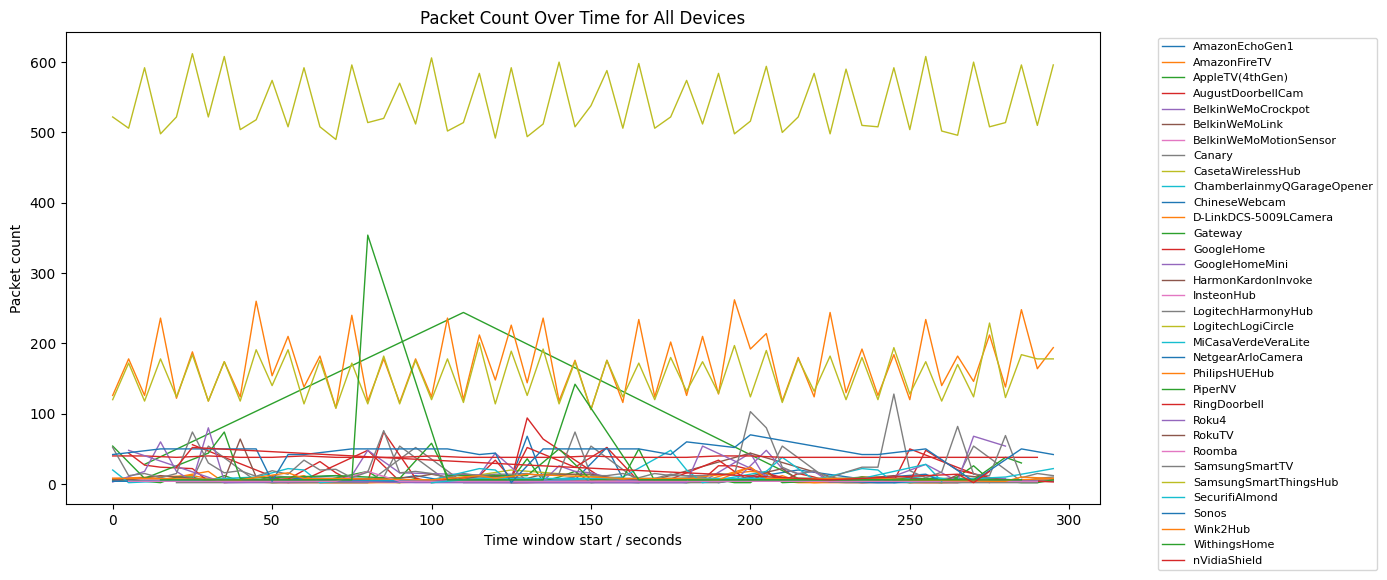

In [19]:
plt.figure(figsize=(14, 6))

for device, device_df in traffic_over_time.groupby("device"):
    plt.plot(device_df["window_start"], device_df["pkt_count"], label=device, linewidth=1)

plt.xlabel("Time window start / seconds")
plt.ylabel("Packet count")
plt.title("Packet Count Over Time for All Devices")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(output_dir / "all_devices_packet_count_over_time.png", dpi=150)
plt.show()

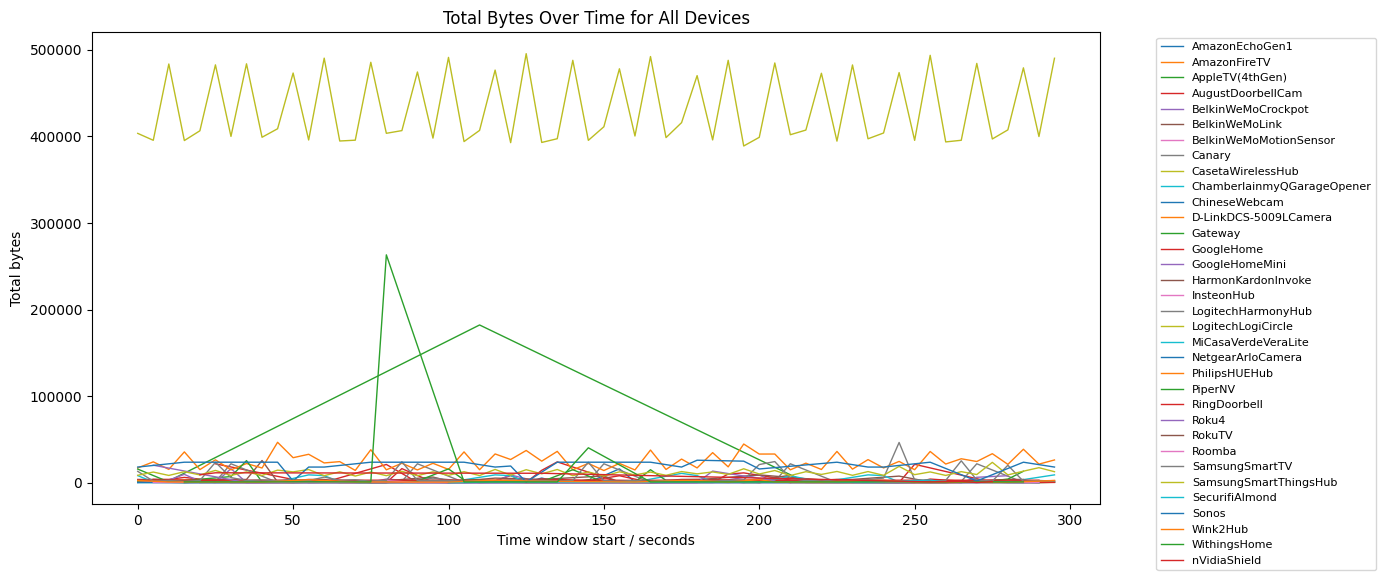

In [20]:
plt.figure(figsize=(14, 6))

for device, device_df in traffic_over_time.groupby("device"):
    plt.plot(device_df["window_start"], device_df["total_bytes"], label=device, linewidth=1)

plt.xlabel("Time window start / seconds")
plt.ylabel("Total bytes")
plt.title("Total Bytes Over Time for All Devices")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(output_dir / "all_devices_total_bytes_over_time.png", dpi=150)
plt.show()

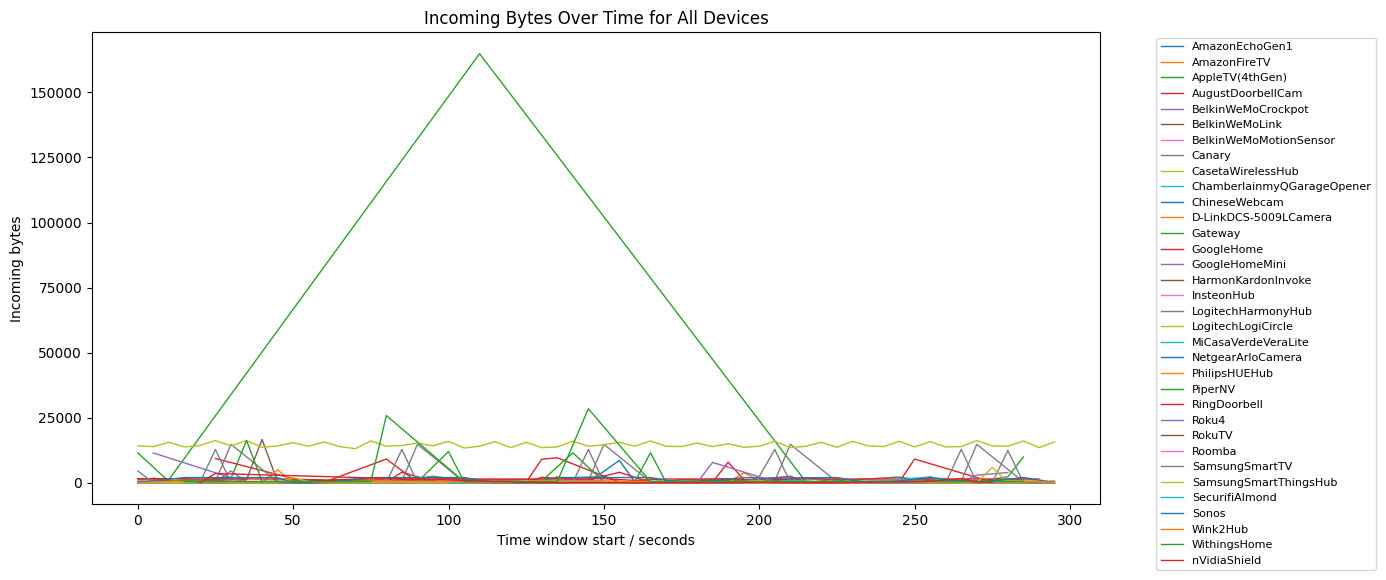

In [21]:
plt.figure(figsize=(14, 6))

for device, device_df in traffic_over_time.groupby("device"):
    plt.plot(device_df["window_start"], device_df["incoming_bytes"], label=device, linewidth=1)

plt.xlabel("Time window start / seconds")
plt.ylabel("Incoming bytes")
plt.title("Incoming Bytes Over Time for All Devices")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(output_dir / "all_devices_incoming_bytes_over_time.png", dpi=150)
plt.show()

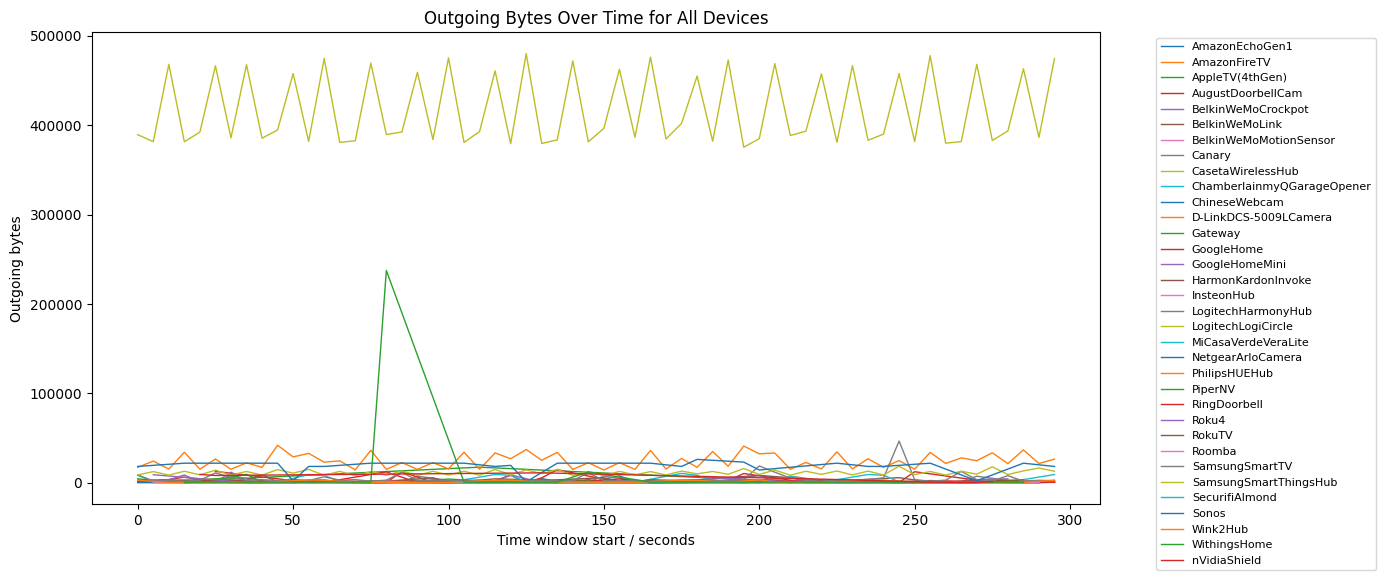

In [22]:
plt.figure(figsize=(14, 6))

for device, device_df in traffic_over_time.groupby("device"):
    plt.plot(device_df["window_start"], device_df["outgoing_bytes"], label=device, linewidth=1)

plt.xlabel("Time window start / seconds")
plt.ylabel("Outgoing bytes")
plt.title("Outgoing Bytes Over Time for All Devices")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(output_dir / "all_devices_outgoing_bytes_over_time.png", dpi=150)
plt.show()

# Classifier

### Device Classification Within Same Day

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

# ============================================================
# Experiment: Device Classification Within Same Day
# Goal:
# Train and test on traffic windows from the same day.
# Label = device
# Features = traffic metadata only
# ============================================================

# -----------------------------
# 0. Make sure window_start exists
# -----------------------------

window_size = 5  # seconds

df_device = df_device.copy()
df_device["time"] = df_device["time"].astype(float)

if "relative_time" not in df_device.columns:
    df_device["relative_time"] = df_device["time"] - df_device["time"].min()

if "window_start" not in df_device.columns:
    df_device["window_start"] = (
        df_device["relative_time"] // window_size
    ) * window_size


# -----------------------------
# 1. Aggregate packets into window-level features
# -----------------------------

feature_df = df_device.groupby(["window_start", "device"]).agg(
    pkt_count=("length", "count"),
    total_bytes=("length", "sum"),
    outgoing_pkts=("direction", lambda x: (x == "outgoing").sum()),
    incoming_pkts=("direction", lambda x: (x == "incoming").sum()),
    outgoing_bytes=("length", lambda x: x[df_device.loc[x.index, "direction"] == "outgoing"].sum()),
    incoming_bytes=("length", lambda x: x[df_device.loc[x.index, "direction"] == "incoming"].sum()),
    avg_pkt_size=("length", "mean"),
    max_pkt_size=("length", "max"),
    min_pkt_size=("length", "min"),
).reset_index()

# Label is the device name
feature_df["label"] = feature_df["device"]

print("Feature table:")
print(feature_df.head())
print("Feature shape:", feature_df.shape)


# -----------------------------
# 2. Select traffic features only
# -----------------------------
# Do NOT include:
# - device: because it is the answer
# - label: because it is the answer
# - window_start: because it may leak time pattern

feature_cols = [
    "pkt_count",
    "total_bytes",
    "outgoing_pkts",
    "incoming_pkts",
    "outgoing_bytes",
    "incoming_bytes",
    "avg_pkt_size",
    "max_pkt_size",
    "min_pkt_size",
]

X = feature_df[feature_cols]
y = feature_df["label"]


# -----------------------------
# 3. Remove devices with too few samples
# -----------------------------
# Stratified split needs enough samples per device.
# Keep devices with at least 10 windows.

min_samples_per_device = 10

label_counts = y.value_counts()
valid_labels = label_counts[label_counts >= min_samples_per_device].index

feature_df_filtered = feature_df[feature_df["label"].isin(valid_labels)].copy()

X = feature_df_filtered[feature_cols]
y = feature_df_filtered["label"]

print("\nAfter filtering:")
print("Samples:", len(feature_df_filtered))
print("Number of devices:", y.nunique())
print(y.value_counts())


# -----------------------------
# 4. Train/test split within the same day
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain samples:", len(X_train))
print("Test samples:", len(X_test))


# -----------------------------
# 5. Train Random Forest
# -----------------------------

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

clf.fit(X_train, y_train)


# -----------------------------
# 6. Evaluate
# -----------------------------

pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("\nDevice Classification Within Same Day")
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, pred, labels=clf.classes_)
cm_df = pd.DataFrame(cm, index=clf.classes_, columns=clf.classes_)
print(cm_df)

Feature table:
   window_start                      device  pkt_count  total_bytes  \
0           0.0              AmazonEchoGen1          4          792   
1           0.0      BelkinWeMoMotionSensor          8          928   
2           0.0  ChamberlainmyQGarageOpener          4          248   
3           0.0       D-LinkDCS-5009LCamera          8         2586   
4           0.0                     Gateway          6         1634   

   outgoing_pkts  incoming_pkts  outgoing_bytes  incoming_bytes  avg_pkt_size  \
0              4              0             792               0    198.000000   
1              4              4             532             396    116.000000   
2              2              2             124             124     62.000000   
3              8              0            2586               0    323.250000   
4              6              0            1634               0    272.333333   

   max_pkt_size  min_pkt_size                       label  
0          

In [25]:
cm_df

,AmazonEchoGen1,AmazonFireTV,AugustDoorbellCam,BelkinWeMoCrockpot,BelkinWeMoLink,Canary,ChamberlainmyQGarageOpener,ChineseWebcam,D-LinkDCS-5009LCamera,Gateway,...,NetgearArloCamera,PhilipsHUEHub,PiperNV,RingDoorbell,Roomba,SamsungSmartTV,SamsungSmartThingsHub,Sonos,Wink2Hub,WithingsHome
AmazonEchoGen1,4,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
AmazonFireTV,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
AugustDoorbellCam,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
BelkinWeMoCrockpot,0,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BelkinWeMoLink,0,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Canary,0,0,0,0,0,6,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ChamberlainmyQGarageOpener,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,6,0,0,0,0,0
ChineseWebcam,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
D-LinkDCS-5009LCamera,0,0,0,0,0,0,0,0,4,0,...,0,0,0,0,0,1,0,0,0,0
Gateway,2,0,0,0,3,0,0,0,0,3,...,0,0,0,0,0,0,0,0,0,0


In [27]:
print(classification_report(y_test, pred))

                            precision    recall  f1-score   support

            AmazonEchoGen1       0.67      0.67      0.67         6
              AmazonFireTV       0.80      0.80      0.80         5
         AugustDoorbellCam       0.50      0.33      0.40         3
        BelkinWeMoCrockpot       1.00      1.00      1.00         2
            BelkinWeMoLink       0.00      0.00      0.00         2
                    Canary       0.86      1.00      0.92         6
ChamberlainmyQGarageOpener       0.00      0.00      0.00         6
             ChineseWebcam       1.00      1.00      1.00         2
     D-LinkDCS-5009LCamera       1.00      0.80      0.89         5
                   Gateway       0.60      0.30      0.40        10
                GoogleHome       0.00      0.00      0.00         8
            GoogleHomeMini       0.75      0.43      0.55         7
        HarmonKardonInvoke       0.88      1.00      0.93         7
        LogitechHarmonyHub       0.60      1.00

In [28]:
print(classification_report(y_test, pred))


                            precision    recall  f1-score   support

            AmazonEchoGen1       0.67      0.67      0.67         6
              AmazonFireTV       0.80      0.80      0.80         5
         AugustDoorbellCam       0.50      0.33      0.40         3
        BelkinWeMoCrockpot       1.00      1.00      1.00         2
            BelkinWeMoLink       0.00      0.00      0.00         2
                    Canary       0.86      1.00      0.92         6
ChamberlainmyQGarageOpener       0.00      0.00      0.00         6
             ChineseWebcam       1.00      1.00      1.00         2
     D-LinkDCS-5009LCamera       1.00      0.80      0.89         5
                   Gateway       0.60      0.30      0.40        10
                GoogleHome       0.00      0.00      0.00         8
            GoogleHomeMini       0.75      0.43      0.55         7
        HarmonKardonInvoke       0.88      1.00      0.93         7
        LogitechHarmonyHub       0.60      1.00